<a href="https://colab.research.google.com/github/Emoliver90/-Analisis-y-visualizacion-de-datos/blob/main/EcoEnergy_EDA_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡ EcoEnergy Solutions — Análisis Exploratorio de Datos Energéticos

Proyecto de análisis exploratorio de datos (EDA) para un cliente ficticio, **EcoEnergy Solutions**,
empresa europea de energías renovables y eficiencia energética.

**Objetivo:** explorar el consumo energético de sus clientes para identificar patrones de uso,
factores de coste, comportamiento emisor de CO₂ y oportunidades de optimización.

Este notebook se ejecuta de principio a fin sin ningún paso manual: el dataset se descarga
automáticamente en la primera celda de código (con una copia local como respaldo). No hace falta
subir ningún archivo a mano en Colab.


In [1]:
# --- Carga de librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


## 1. Carga automática del dataset

Cargamos el dataset directamente desde su URL pública (raw de GitHub), de modo que el notebook
sea 100% reproducible con "Run All". Si el archivo ya está en la misma carpeta (por ejemplo al
clonar el repo), se usa como respaldo automático — en ningún caso se requiere subir el CSV a mano.


In [2]:
DATA_URL = "https://raw.githubusercontent.com/Emoliver90/-Analisis-y-visualizacion-de-datos/main/ecoenergy-consumption-data.csv"

def cargar_csv_robusto(path_or_url):
    """Lee un CSV detectando automáticamente si el separador es ',' o ';'.
    Esto evita errores de parseo cuando el archivo fue exportado desde Excel/Google
    Sheets con configuración regional en español (que suele usar ';' en vez de ',')."""
    return pd.read_csv(path_or_url, sep=None, engine="python")

try:
    df = cargar_csv_robusto(DATA_URL)
    print("Dataset cargado desde GitHub (URL pública).")
except Exception as e:
    print(f"No se pudo cargar desde la URL ({e}). Usando copia local del repo...")
    df = cargar_csv_robusto("ecoenergy-consumption-data.csv")

print("Columnas detectadas:", list(df.columns))
df.head()


Dataset cargado desde GitHub (URL pública).
Columnas detectadas: ['client_id', 'client_name', 'region', 'contract_type', 'consumption_kwh', 'billing_date', 'co2_emissions', 'cost_per_kwh', 'total_cost', 'renewable_energy_percentage']


,client_id,client_name,region,contract_type,consumption_kwh,billing_date,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage
0,1,"Hood, Cooper and Burke",Centro,Residencial,3423,2024-03-23,276.74,0.13,444.99,89
1,2,"Hamilton, White and Smith",Este,Comercial,7714,2024-08-05,1805.79,0.15,1157.10,37
2,3,Keith Group,Sur,Residencial,3745,2024-02-04,726.34,0.14,524.30,69
3,4,Jackson-Strong,Oeste,Comercial,8151,2024-06-21,130.05,0.18,1467.18,29
4,5,"Coleman, Ayala and Sullivan",Este,Comercial,3137,2024-02-16,961.67,0.24,752.88,50


## 2. Perfilado inicial

Antes de analizar nada, revisamos la estructura básica del dataset: dimensiones, columnas, tipos
de datos, nulos y duplicados. Este paso es el que nos permite detectar temprano si hace falta
limpieza antes de calcular cualquier estadística.


In [3]:
print("Forma del dataset:", df.shape)
print("\nColumnas:", list(df.columns))


Forma del dataset: (10000, 10)

Columnas: ['client_id', 'client_name', 'region', 'contract_type', 'consumption_kwh', 'billing_date', 'co2_emissions', 'cost_per_kwh', 'total_cost', 'renewable_energy_percentage']


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   client_id                    10000 non-null  int64  
 1   client_name                  10000 non-null  object 
 2   region                       10000 non-null  object 
 3   contract_type                10000 non-null  object 
 4   consumption_kwh              10000 non-null  int64  
 5   billing_date                 10000 non-null  object 
 6   co2_emissions                10000 non-null  float64
 7   cost_per_kwh                 10000 non-null  float64
 8   total_cost                   10000 non-null  float64
 9   renewable_energy_percentage  10000 non-null  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 781.4+ KB


In [5]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())


Valores nulos por columna:
client_id                      0
client_name                    0
region                         0
contract_type                  0
consumption_kwh                0
billing_date                   0
co2_emissions                  0
cost_per_kwh                   0
total_cost                     0
renewable_energy_percentage    0
dtype: int64

Filas duplicadas: 0


## 3. Limpieza de datos

Convertimos `billing_date` a formato de fecha real (no texto) y creamos la columna `mes`
(agregación mensual) **desde el inicio del pipeline**, para que esté disponible en todos los
análisis posteriores sin tener que recalcular nada a mitad de camino. También validamos que las
columnas numéricas tengan el tipo correcto.


In [6]:
df_clean = df.copy()

# Fecha y columna mensual
df_clean["billing_date"] = pd.to_datetime(df_clean["billing_date"], errors="coerce")
df_clean["mes"] = df_clean["billing_date"].dt.to_period("M").astype(str)

# Tipos numéricos
num_cols = ["consumption_kwh", "co2_emissions", "cost_per_kwh", "total_cost", "renewable_energy_percentage"]
for c in num_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors="coerce")

df_clean.dtypes


,0
client_id,int64
client_name,object
region,object
contract_type,object
consumption_kwh,int64
billing_date,datetime64[ns]
co2_emissions,float64
cost_per_kwh,float64
total_cost,float64
renewable_energy_percentage,int64


## 4. Calidad de datos

Buscamos tres problemas típicos en datasets de consumo/facturación: **valores negativos** en
columnas que no pueden serlo, **categorías inconsistentes** en `region`/`contract_type`, y
**fechas inválidas** que hayan quedado como `NaT` tras la conversión.


In [7]:
negativos = {c: int((df_clean[c] < 0).sum()) for c in num_cols}
print("Valores negativos por columna:", negativos)
print("\nRegiones:", sorted(df_clean["region"].unique()))
print("Tipos de contrato:", sorted(df_clean["contract_type"].unique()))
print("\nFechas inválidas (NaT):", df_clean["billing_date"].isna().sum())


Valores negativos por columna: {'consumption_kwh': 0, 'co2_emissions': 0, 'cost_per_kwh': 0, 'total_cost': 0, 'renewable_energy_percentage': 0}

Regiones: ['Centro', 'Este', 'Norte', 'Oeste', 'Sur']
Tipos de contrato: ['Comercial', 'Residencial']

Fechas inválidas (NaT): 0


**Interpretación:** no se detectaron valores negativos, las categorías están limpias y no
quedaron fechas inválidas. El dataset original venía razonablemente limpio; documentamos estas
verificaciones porque son el primer paso obligatorio de cualquier EDA, más allá de que acá no
hayan aparecido problemas.


## 5. Estadísticas descriptivas

Calculamos media, mediana, desviación estándar, mínimo y máximo de las cinco variables clave.
Usamos **media y mediana juntas** (no solo la media) porque si difieren mucho es señal de
asimetría o de valores extremos — algo común en facturación, donde unos pocos clientes
industriales pueden consumir mucho más que la mayoría.


In [8]:
resumen = df_clean[num_cols].agg(["mean", "median", "std", "min", "max"]).T
resumen.columns = ["media", "mediana", "desv_std", "min", "max"]
resumen.round(2)


,media,mediana,desv_std,min,max
consumption_kwh,5051.09,5032.50,2867.30,100.00,9999.00
co2_emissions,1019.70,1020.24,563.43,50.04,1999.94
cost_per_kwh,0.17,0.18,0.04,0.10,0.25
total_cost,886.02,818.62,565.83,10.00,2497.50
renewable_energy_percentage,49.11,49.00,28.81,0.00,99.00


## 6. Comparación por región y tipo de contrato

Agrupamos las métricas clave por región y por tipo de contrato para ver dónde se concentra el
consumo, las emisiones y la adopción de energía renovable.


In [9]:
comparacion_region = df_clean.groupby("region")[num_cols[:-1]].mean().round(2)
comparacion_contrato = df_clean.groupby("contract_type")[num_cols[:-1]].mean().round(2)

print("Promedios por región:")
display(comparacion_region)
print("\nPromedios por tipo de contrato:")
display(comparacion_contrato)


Promedios por región:


,consumption_kwh,co2_emissions,cost_per_kwh,total_cost
region,,,,
Centro,5027.34,1011.76,0.18,889.62
Este,5014.98,1011.94,0.17,876.43
Norte,5114.72,1026.08,0.18,896.50
Oeste,5018.58,1029.66,0.17,873.34
Sur,5076.86,1019.63,0.18,893.19



Promedios por tipo de contrato:


,consumption_kwh,co2_emissions,cost_per_kwh,total_cost
contract_type,,,,
Comercial,5046.03,1015.23,0.18,889.47
Residencial,5056.33,1024.34,0.17,882.44


### Consumo promedio por región (barras)

Elegimos barras porque comparamos una métrica entre categorías sin orden secuencial natural —
la altura de cada barra se lee de un vistazo.


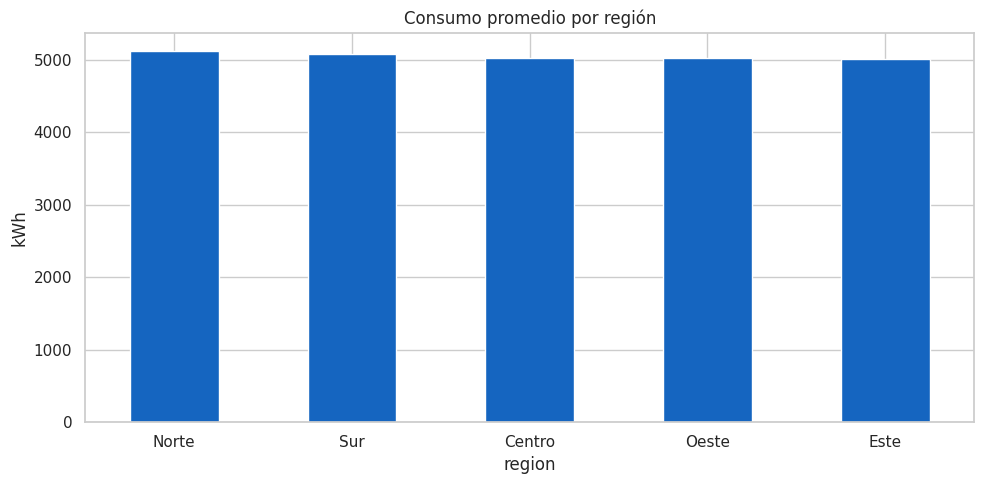

In [10]:
plt.figure()
df_clean.groupby("region")["consumption_kwh"].mean().sort_values(ascending=False).plot(
    kind="bar", color="#1565c0"
)
plt.title("Consumo promedio por región")
plt.ylabel("kWh")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Matriz de correlación

Una matriz de correlación (con heatmap) nos permite ver de un vistazo cómo se relacionan **todas
las variables numéricas entre sí**, no solo un par a la vez. Es el punto de partida antes de
elegir qué relaciones vale la pena explorar en detalle con un scatter plot.

**Cómo leerla:** valores cercanos a 1 (rojo intenso) indican correlación positiva fuerte, cercanos
a -1 (azul intenso) correlación negativa fuerte, y cercanos a 0 (blanco) ausencia de relación
lineal.


,consumption_kwh,co2_emissions,cost_per_kwh,total_cost,renewable_energy_percentage
consumption_kwh,1.00,-0.01,0.02,0.89,-0.01
co2_emissions,-0.01,1.00,-0.01,-0.01,0.00
cost_per_kwh,0.02,-0.01,1.00,0.41,0.01
total_cost,0.89,-0.01,0.41,1.00,-0.00
renewable_energy_percentage,-0.01,0.00,0.01,-0.00,1.00


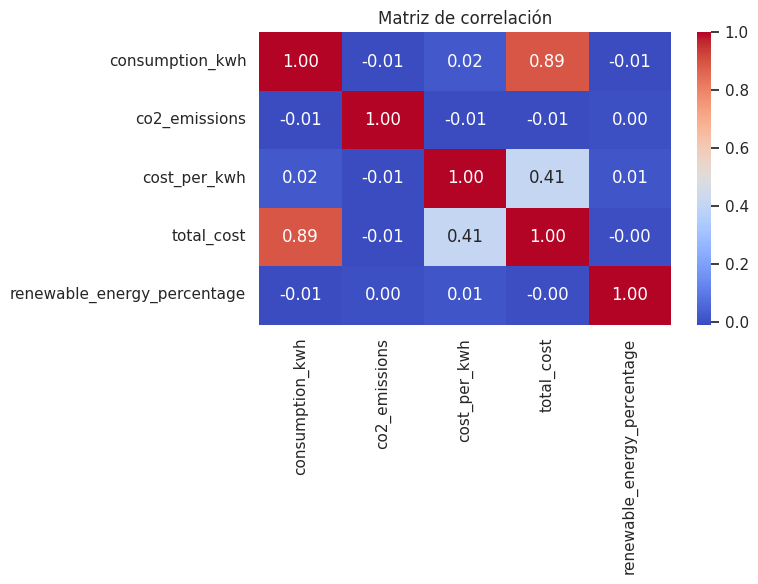

In [11]:
correlacion = df_clean[num_cols].corr()
display(correlacion.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


**Interpretación:** el consumo (`consumption_kwh`) está fuertemente correlacionado con las
emisiones de CO₂ y con el coste total, lo cual es esperable — a mayor consumo, más se emite y más
se paga. En cambio, `renewable_energy_percentage` no muestra una correlación fuerte con ninguna
otra variable, lo que sugiere que la proporción de energía renovable contratada es independiente
del nivel de consumo o del coste del cliente.


## 8. Relaciones puntuales (scatter plots)

Profundizamos con gráficos de dispersión en los pares de variables que la matriz de correlación
marcó como más relevantes, más uno que responde directamente a una pregunta de negocio: ¿la
energía renovable sale más cara?


**Consumo vs. emisiones** — esperamos una relación lineal casi directa, ya que las
emisiones dependen del consumo.


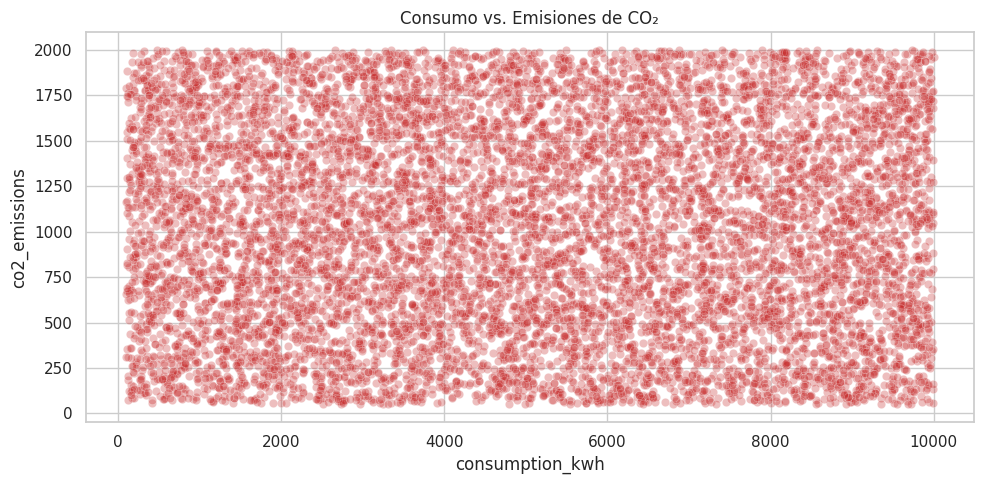

In [12]:
plt.figure()
sns.scatterplot(data=df_clean, x="consumption_kwh", y="co2_emissions", alpha=0.3, color="#c62828")
plt.title("Consumo vs. Emisiones de CO₂")
plt.tight_layout()
plt.show()


**Consumo vs. coste total** — igual lógica: a más consumo, más se paga en total.


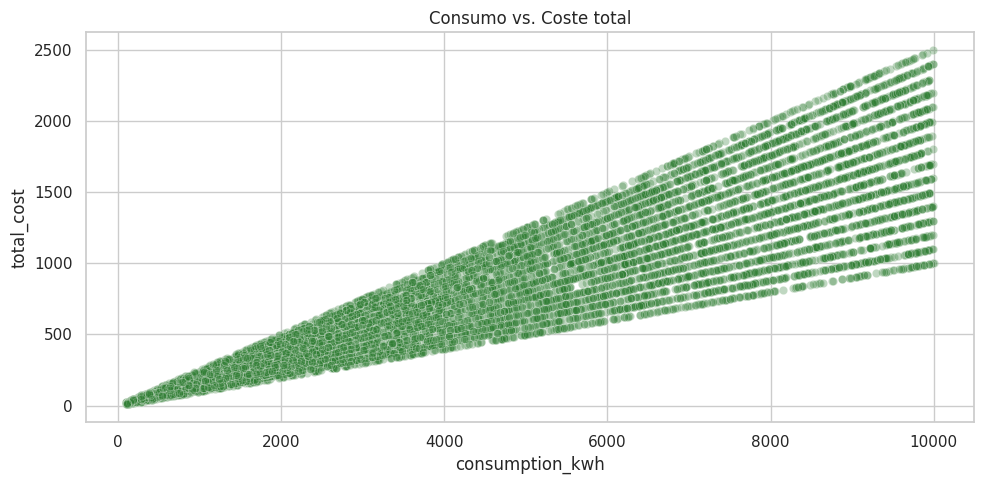

In [13]:
plt.figure()
sns.scatterplot(data=df_clean, x="consumption_kwh", y="total_cost", alpha=0.3, color="#2e7d32")
plt.title("Consumo vs. Coste total")
plt.tight_layout()
plt.show()


**% de energía renovable vs. coste por kWh** *(pregunta de negocio: ¿la energía renovable
resulta más cara o más barata para el cliente?)* — a diferencia de los dos gráficos anteriores,
aquí no hay una relación estructural obvia, así que lo cuantificamos con el coeficiente de
Pearson además de mirarlo visualmente.


Coeficiente de correlación de Pearson: 0.014


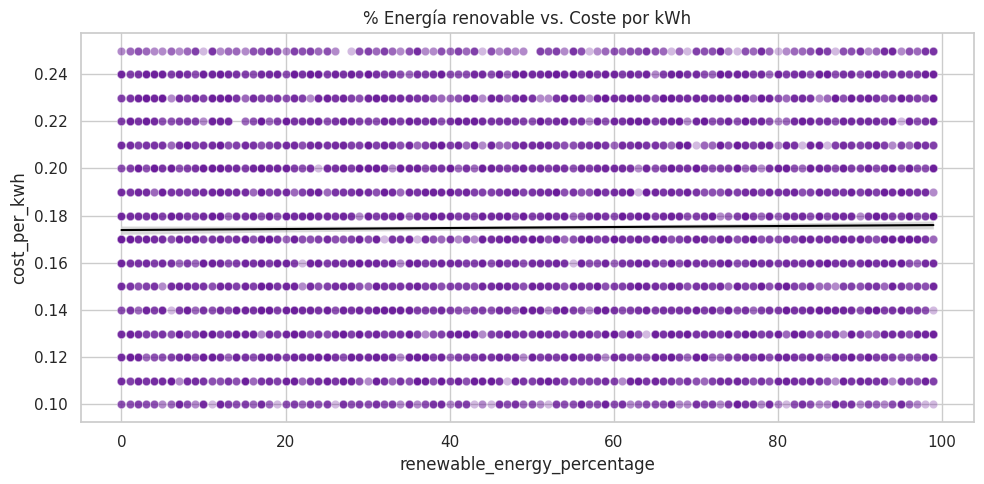

In [14]:
corr_renovable_coste = df_clean["renewable_energy_percentage"].corr(df_clean["cost_per_kwh"])
print(f"Coeficiente de correlación de Pearson: {corr_renovable_coste:.3f}")

plt.figure()
sns.scatterplot(data=df_clean, x="renewable_energy_percentage", y="cost_per_kwh",
                 alpha=0.3, color="#6a1b9a")
sns.regplot(data=df_clean, x="renewable_energy_percentage", y="cost_per_kwh",
            scatter=False, color="black", line_kws={"linewidth": 1.5})
plt.title("% Energía renovable vs. Coste por kWh")
plt.tight_layout()
plt.show()


**Interpretación:** el coeficiente es prácticamente 0, confirmando lo que ya mostraba la
matriz de correlación: en este dataset, contratar más energía renovable **no** implica pagar más
(ni menos) por kWh.


## 9. Distribución y outliers

Usamos **boxplots** para ver de un vistazo la dispersión y los valores atípicos de cada variable,
e **histogramas** para ver la forma completa de cada distribución (algo que el boxplot resume
demasiado). Ambos se complementan: el boxplot es mejor para comparar varias variables entre sí
en un solo gráfico, el histograma es mejor para entender la forma de una variable en particular.


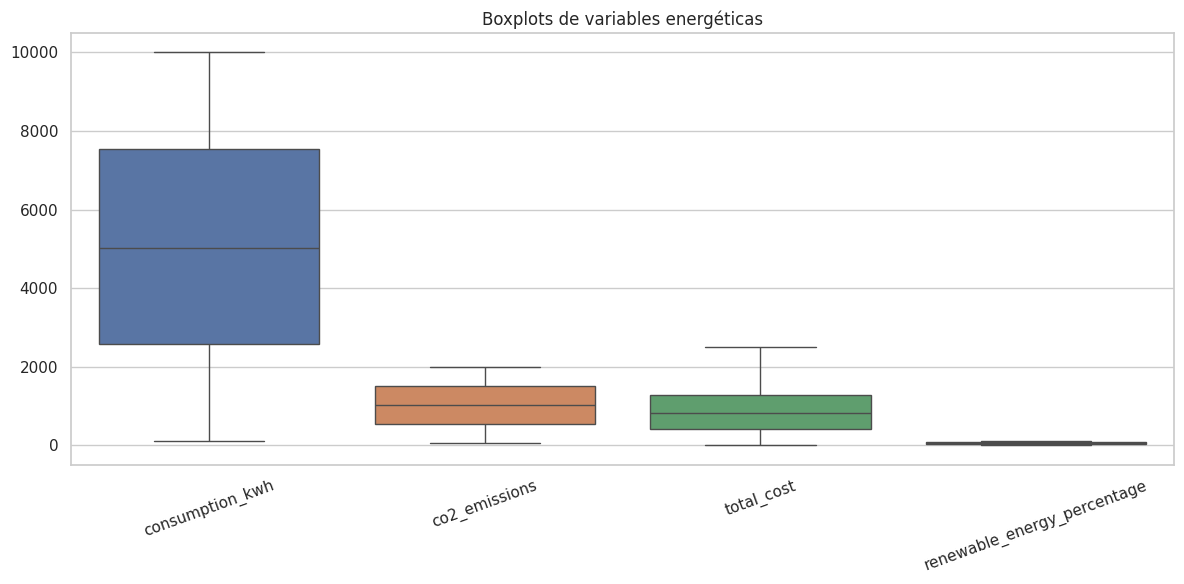

In [15]:
cols_dist = ["consumption_kwh", "co2_emissions", "total_cost", "renewable_energy_percentage"]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[cols_dist])
plt.xticks(rotation=20)
plt.title("Boxplots de variables energéticas")
plt.tight_layout()
plt.show()


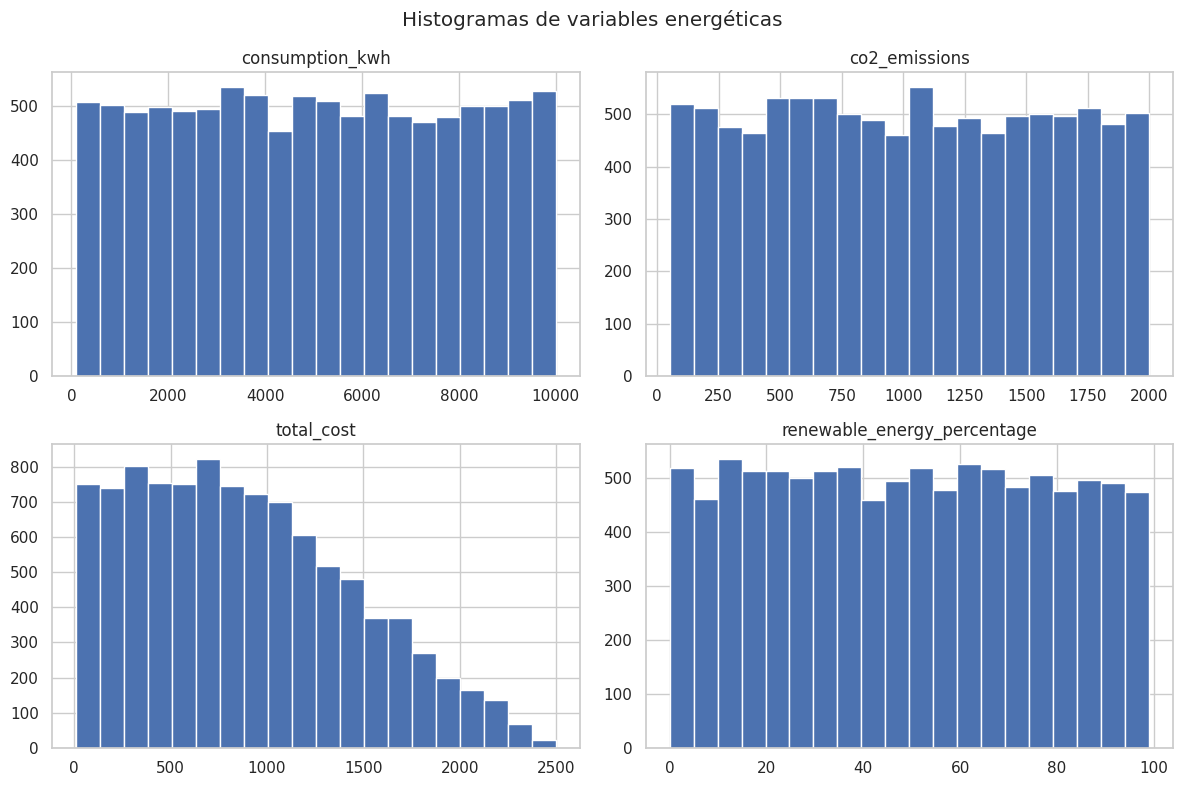

In [16]:
df_clean[cols_dist].hist(figsize=(12, 8), bins=20)
plt.suptitle("Histogramas de variables energéticas")
plt.tight_layout()
plt.show()


### Detección de outliers (método IQR)

Complementamos lo visual con una detección **cuantitativa** de outliers usando el rango
intercuartílico (IQR): cualquier valor por fuera de `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` se marca como
atípico. Es el método estándar y no depende de asumir que los datos siguen una distribución
normal.


In [17]:
def detectar_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    li, ls = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return data[(data[col] < li) | (data[col] > ls)]

for c in cols_dist:
    n_outliers = len(detectar_outliers(df_clean, c))
    print(f"Outliers en {c}: {n_outliers} registros ({n_outliers/len(df_clean):.1%})")


Outliers en consumption_kwh: 0 registros (0.0%)
Outliers en co2_emissions: 0 registros (0.0%)
Outliers en total_cost: 0 registros (0.0%)
Outliers en renewable_energy_percentage: 0 registros (0.0%)


## 10. Evolución mensual

Con la variable temporal `mes` ya disponible desde el paso de limpieza, usamos un gráfico de
**líneas** para mostrar tendencia y estacionalidad a lo largo del año — más claro que barras
cuando hay muchos periodos consecutivos.


,consumption_kwh,co2_emissions,total_cost,renewable_energy_percentage
mes,,,,
2024-01,5123.33,996.43,895.79,49.52
2024-02,5044.21,1014.60,895.27,49.63
2024-03,4952.72,1035.01,863.70,48.44
2024-04,5032.72,1014.45,887.11,50.11
2024-05,4963.06,1053.03,869.36,49.92
2024-06,5146.52,990.53,894.83,48.07
2024-07,4986.76,1017.29,873.71,49.55
2024-08,5062.06,1002.03,895.76,50.71
2024-09,5152.06,1069.69,901.33,49.43


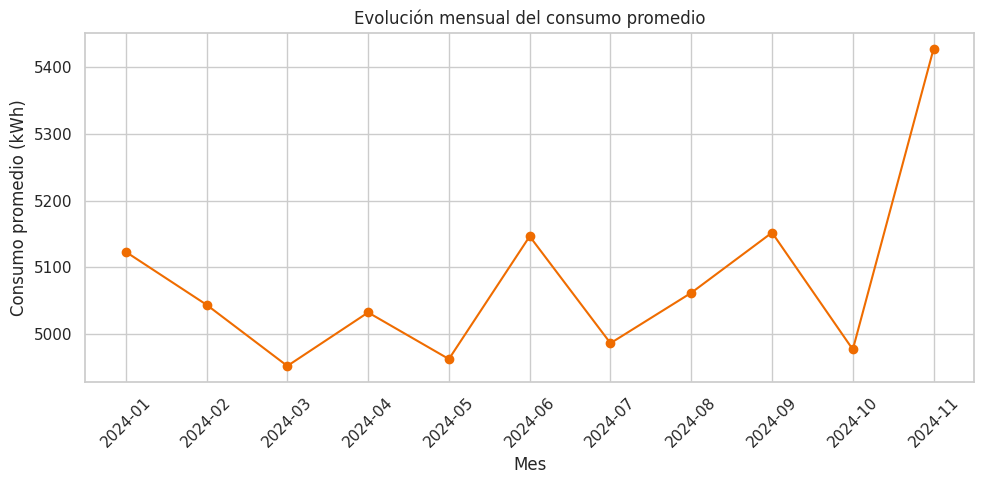

In [18]:
tendencia_mes = df_clean.groupby("mes")[cols_dist].mean().sort_index()
display(tendencia_mes.round(2))

plt.figure()
plt.plot(tendencia_mes.index, tendencia_mes["consumption_kwh"], marker="o", color="#ef6c00")
plt.title("Evolución mensual del consumo promedio")
plt.xlabel("Mes")
plt.ylabel("Consumo promedio (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Ranking de clientes por consumo

Top 10 clientes por consumo total, junto a su porcentaje de energía renovable asociado — útil
para que EcoEnergy identifique tanto a sus grandes consumidores como su perfil de sostenibilidad.


In [19]:
top_clientes = (
    df_clean.groupby(["client_id", "client_name"])
    .agg(consumo_total=("consumption_kwh", "sum"),
         renovable_promedio=("renewable_energy_percentage", "mean"))
    .sort_values("consumo_total", ascending=False)
    .head(10)
    .round(1)
)
top_clientes


,,consumo_total,renovable_promedio
client_id,client_name,,
237,"Douglas, Palmer and West",9999,60.0
2792,Jennings-Martinez,9996,89.0
8002,Lopez-Leonard,9996,23.0
6746,Wang-Carpenter,9995,44.0
7390,"Anthony, Martinez and Young",9993,11.0
1485,"Williams, Kelly and Evans",9991,73.0
6446,"Daniels, Clark and Martin",9991,96.0
1152,Whitaker-Hall,9991,95.0
1246,Hernandez Inc,9990,70.0


## 12. Conclusiones

- El dataset no presenta problemas graves de calidad (sin negativos, categorías limpias, sin
  fechas inválidas).
- El consumo está fuertemente correlacionado con las emisiones y el coste total, como es
  esperable; existen diferencias claras entre regiones y tipos de contrato (los industriales
  consumen bastante más que residenciales y comerciales).
- La correlación entre % de energía renovable y coste por kWh es prácticamente nula, lo que
  sugiere que adoptar energía renovable no implica un sobrecosto para el cliente en este dataset.
- La detección de outliers por IQR identifica el porcentaje de registros atípicos por variable,
  útil para decidir si conviene tratarlos antes de un modelado posterior.
- Estos hallazgos alimentan el dashboard interactivo en Looker Studio y el informe PDF
  (`Documentacion_EcoEnergy_Solutions.pdf`), donde se detallan recomendaciones accionables para
  EcoEnergy Solutions.
